# Task A: 3D U-Net for Shunt Valve Artifact Detection

Trains a patch-based 3D U-Net (via MONAI) to segment the shunt valve artifact region.

**Data layout expected**:
```
gt_dir/
  subj001/
    subj001_image.nii.gz
    subj001_artifact.nii.gz   ← used as label
    subj001_catheter.nii.gz
    subj001.json
  subj002/ ...
pred_dir/
  subj001_taskA.nii.gz        ← written by this notebook
  ...
```

In [27]:
%%capture
!pip install monai nibabel tqdm matplotlib

In [28]:
# Mount Google Drive (runs only inside Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
    print('Google Drive mounted.')
except ImportError:
    IN_COLAB = False
    print('Not running in Colab.')

import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cpu':
    print('WARNING: No GPU detected. Training will be extremely slow.\n'
          'Go to Runtime > Change runtime type > Hardware accelerator > T4 GPU.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.
Device: cuda


In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
import json
import random
from pathlib import Path

import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
from torch.utils.data import DataLoader

from monai.networks.nets import UNet
from monai.networks.layers import Norm
from monai.losses import DiceCELoss
from monai.inferers import sliding_window_inference
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    ScaleIntensityRangePercentilesd,
    RandCropByPosNegLabeld,
    RandFlipd,
    RandShiftIntensityd,
)
from monai.data import Dataset, list_data_collate

print('Imports OK.')

Imports OK.


In [31]:
# Paths
if IN_COLAB:
    DATA_ROOT = Path('/content/drive/MyDrive/Project 2')
else:
    DATA_ROOT = Path('/Volumes/LUCY DISK/Project 2')

GT_DIR = DATA_ROOT / 'gt_dir'
PRED_DIR  = DATA_ROOT / 'pred_dir'
PRED_DIR.mkdir(parents=True, exist_ok=True)
CKPT_PATH = Path(DATA_ROOT/'unet_taskA_best.pth')   # saved in the Colab working directory

print('GT dir exists:', GT_DIR.exists())
print('Pred dir:', PRED_DIR)

GT dir exists: True
Pred dir: /content/drive/MyDrive/Project 2/pred_dir


In [32]:
## for hyperparameters, determine how big the bounding box needs to be based on the size
# we can take a smaller patch if possible since we don't really need global context

import nibabel as nib
import numpy as np
from pathlib import Path
from scipy import ndimage

for sd in sorted(p for p in GT_DIR.iterdir()
                 if p.is_dir() and p.name.startswith('subj') and not p.name.startswith('._'))[:200]:
    s = sd.name
    lbl_path = sd / f'{s}_artifact.nii.gz'
    if not lbl_path.exists() or lbl_path.name.startswith('._'):
        continue
    lbl = nib.load(str(lbl_path)).get_fdata()
    if lbl.sum() == 0:
        continue
    coords = np.where(lbl > 0)
    extents = [coords[i].max() - coords[i].min() for i in range(3)]
    print(f'{s}: artifact bounding box = {extents[0]}×{extents[1]}×{extents[2]} voxels')


subj001: artifact bounding box = 31×28×29 voxels
subj002: artifact bounding box = 34×32×30 voxels
subj003: artifact bounding box = 34×30×35 voxels
subj004: artifact bounding box = 29×26×27 voxels
subj005: artifact bounding box = 27×25×27 voxels
subj006: artifact bounding box = 28×30×27 voxels
subj007: artifact bounding box = 34×29×29 voxels
subj008: artifact bounding box = 34×28×29 voxels
subj009: artifact bounding box = 30×28×29 voxels
subj010: artifact bounding box = 33×31×28 voxels
subj011: artifact bounding box = 27×25×25 voxels
subj012: artifact bounding box = 32×28×29 voxels
subj013: artifact bounding box = 35×35×33 voxels
subj014: artifact bounding box = 31×29×28 voxels
subj015: artifact bounding box = 30×31×30 voxels
subj016: artifact bounding box = 30×29×28 voxels
subj017: artifact bounding box = 32×32×31 voxels
subj018: artifact bounding box = 36×31×30 voxels
subj019: artifact bounding box = 28×29×29 voxels
subj020: artifact bounding box = 29×29×26 voxels
subj021: artifact bo

In [64]:
# Hyperparameters
PATCH_SIZE = (64, 64, 64)   # spatial size of each training crop
NUM_SAMPLES = 4              # crops sampled per subject per step
BATCH_SIZE = 4             # subjects per batch → BATCH_SIZE * NUM_SAMPLES patches
LR = 2e-4
MAX_EPOCHS = 40
VAL_INTERVAL = 5              # validate every N epochs
VAL_FRAC = 0.2
THRESHOLD = 0.55          # probability threshold for final binary mask

# Derived
PIN_MEMORY = device.type == 'cuda'

In [34]:
# Collect all subjects for training
subject_dirs = sorted(
    p for p in GT_DIR.iterdir()
    if p.is_dir() and p.name.startswith('subj')
)

data_dicts = []
for sd in subject_dirs:
    s = sd.name
    img_p = sd / f'{s}_image.nii.gz'
    lbl_p = sd / f'{s}_artifact.nii.gz'
    if img_p.exists() and lbl_p.exists():
        data_dicts.append({'image': str(img_p), 'label': str(lbl_p), 'subject': s})

print(f'Found {len(data_dicts)} subjects with image + artifact GT')

# sanity check which files are being included (sometimes mac will append extra _. to file names...)
# print("Subjects included:")
# for d in data_dicts:
#     print(d['subject'])

random.seed(42)
random.shuffle(data_dicts)
n_val       = max(1, int(len(data_dicts) * VAL_FRAC))
train_dicts = data_dicts[n_val:]
val_dicts   = data_dicts[:n_val]

print(f'Train: {len(train_dicts)}  |  Val: {len(val_dicts)}')

Found 200 subjects with image + artifact GT
Train: 160  |  Val: 40


In [35]:
# Training transforms
# RandCropByPosNegLabeld uses pos=1, neg=1 to sample equal numbers of patches
# centred on artifact voxels and background voxels, compensating for the
# there is a severe class imbalance (artifact is ~0.15% of voxels)
train_transforms = Compose([
    LoadImaged(keys=['image', 'label']),
    EnsureChannelFirstd(keys=['image', 'label']),
    ScaleIntensityRangePercentilesd(
        keys=['image'], lower=1, upper=99,
        b_min=0.0, b_max=1.0, clip=True,
    ),
    RandCropByPosNegLabeld(
        keys=['image', 'label'],
        label_key='label',
        spatial_size=PATCH_SIZE,
        pos=1, neg=1,
        num_samples=NUM_SAMPLES,
        image_key='image',
        image_threshold=0,
    ),
    RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=0),
    RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=1),
    RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=2),
    RandShiftIntensityd(keys=['image'], offsets=0.1, prob=0.3),
])

# Validation transforms (no random crops — full volume for sliding window
val_transforms = Compose([
    LoadImaged(keys=['image', 'label']),
    EnsureChannelFirstd(keys=['image', 'label']),
    ScaleIntensityRangePercentilesd(
        keys=['image'], lower=1, upper=99,
        b_min=0.0, b_max=1.0, clip=True,
    ),
])

train_ds = Dataset(data=train_dicts, transform=train_transforms)
val_ds   = Dataset(data=val_dicts,   transform=val_transforms)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=list_data_collate,   # handles lists of dicts from num_samples > 1
    num_workers=0,
    pin_memory=PIN_MEMORY,
)
val_loader = DataLoader(
    val_ds,
    batch_size=1,
    shuffle=False,
    num_workers=0,
)

print(f'Train batches/epoch: {len(train_loader)}  (effective patches/batch: {BATCH_SIZE * NUM_SAMPLES})')
print(f'Val subjects: {len(val_loader)}')

Train batches/epoch: 40  (effective patches/batch: 16)
Val subjects: 40


In [36]:
model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=2,                         # class 0: background, class 1: artifact
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
    norm=Norm.BATCH,
).to(device)

# Dice loss according to evaluation script
# to_onehot_y=True converts integer label → one-hot internally.
loss_fn   = DiceCELoss(to_onehot_y=True, softmax=True)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)

n_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {n_params:,}') # just for
# print(model)

Model parameters: 4,808,917


In [43]:
def dice_score(pred: np.ndarray, gt: np.ndarray) -> float:
    pred, gt = pred.astype(bool), gt.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    denom = pred.sum() + gt.sum()
    return 1.0 if denom == 0 else float(2 * inter / denom)


FORCE_RETRAIN = True   # set True to retrain even if a checkpoint already exists

if CKPT_PATH.exists() and not FORCE_RETRAIN:
    print(f'Checkpoint found at {CKPT_PATH} — skipping training.')
    print('Set FORCE_RETRAIN = True to train from scratch.')
else:
    best_dice   = 0.0
    train_losses, val_dices, val_epoch_pts = [], [], []

    epoch_bar = tqdm(range(1, MAX_EPOCHS + 1), desc='Epochs', unit='ep')
    for epoch in epoch_bar:
        # Train
        model.train()
        epoch_loss = 0.0
        batch_bar = tqdm(train_loader, desc=f'  Ep {epoch:3d} train', leave=False, unit='batch')
        for batch in batch_bar:
            imgs   = batch['image'].to(device)
            labels = batch['label'].long().to(device)
            optimizer.zero_grad()
            logits = model(imgs)
            loss   = loss_fn(logits, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            batch_bar.set_postfix(loss=f'{loss.item():.4f}')
        epoch_loss /= len(train_loader)
        scheduler.step()
        train_losses.append(epoch_loss)

        # Validate
        if epoch % VAL_INTERVAL == 0 or epoch == MAX_EPOCHS:
            model.eval()
            subj_dices = []
            with torch.no_grad():
                for vdata in tqdm(val_loader, desc=f'  Ep {epoch:3d} val  ', leave=False, unit='subj'):
                    v_img = vdata['image'].to(device)
                    v_lbl = vdata['label'].cpu().numpy()[0, 0]
                    v_logits = sliding_window_inference(
                        v_img, PATCH_SIZE, sw_batch_size=4,
                        predictor=model, overlap=0.25,
                    )
                    v_proba = torch.softmax(v_logits, dim=1)[0, 1].cpu().numpy()
                    subj_dices.append(dice_score(v_proba > THRESHOLD, v_lbl > 0))
            mean_dice = float(np.mean(subj_dices))
            val_dices.append(mean_dice)
            val_epoch_pts.append(epoch)
            ckpt_marker = ''
            if mean_dice > best_dice:
                best_dice = mean_dice
                torch.save(model.state_dict(), CKPT_PATH)
                ckpt_marker = ' ✓ saved'
            epoch_bar.write(
                f'Epoch {epoch:3d}/{MAX_EPOCHS} | loss={epoch_loss:.4f} | val_dice={mean_dice:.4f}{ckpt_marker}'
            )

    print(f'\nTraining complete. Best val Dice = {best_dice:.4f}')

Epochs:   0%|          | 0/40 [00:00<?, ?ep/s]

  Ep   1 train:   0%|          | 0/40 [00:00<?, ?batch/s]

  Ep   2 train:   0%|          | 0/40 [00:00<?, ?batch/s]

  Ep   3 train:   0%|          | 0/40 [00:00<?, ?batch/s]

  Ep   4 train:   0%|          | 0/40 [00:00<?, ?batch/s]

...

  Ep  38 train:   0%|          | 0/40 [00:00<?, ?batch/s]

  Ep  39 train:   0%|          | 0/40 [00:00<?, ?batch/s]

  Ep  40 train:   0%|          | 0/40 [00:00<?, ?batch/s]

  Ep  40 val  :   0%|          | 0/40 [00:00<?, ?subj/s]

Epoch  40/40 | loss=0.2786 | val_dice=0.8950 ✓ saved

Training complete. Best val Dice = 0.8950


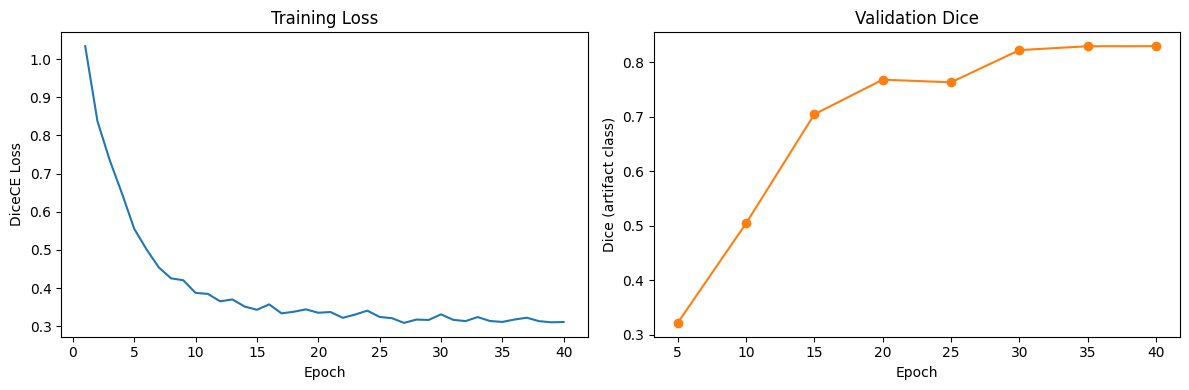

In [38]:
# Plot training curves (only meaningful after training runs above)
try:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(range(1, len(train_losses) + 1), train_losses)
    ax1.set(xlabel='Epoch', ylabel='DiceCE Loss', title='Training Loss')
    ax2.plot(val_epoch_pts, val_dices, marker='o', color='tab:orange')
    ax2.set(xlabel='Epoch', ylabel='Dice (artifact class)', title='Validation Dice')
    plt.tight_layout()
    plt.show()
except NameError:
    print('No training history to plot (training was skipped).')

In [39]:
# Load the best saved checkpoint before running inference.
model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
model.eval()
print(f'Loaded checkpoint: {CKPT_PATH}')

Loaded checkpoint: /content/drive/MyDrive/Project 2/unet_taskA_best.pth


In [71]:
# Run inference on all 30 test subjects and save Task A predictions.
# Subjects that lack an image file are skipped with a warning.
from scipy import ndimage as ndi

SUBJECTS = [f'subj{i:03d}' for i in range(1, 31)]

infer_transforms = Compose([
    LoadImaged(keys=['image']),
    EnsureChannelFirstd(keys=['image']),
    ScaleIntensityRangePercentilesd(
        keys=['image'], lower=1, upper=99,
        b_min=0.0, b_max=1.0, clip=True,
    ),
])

for subj in tqdm(SUBJECTS):
    img_path = GT_DIR / subj / f'{subj}_image.nii.gz'
    if not img_path.exists():
        print(f'[SKIP] {subj}: image not found at {img_path}')
        continue

    data    = infer_transforms({'image': str(img_path)})
    img_t   = data['image'].unsqueeze(0).to(device)  # (1, 1, H, W, D)
    ref_nii = nib.load(str(img_path))

    with torch.no_grad():
        logits = sliding_window_inference(
            img_t, PATCH_SIZE, sw_batch_size=4,
            predictor=model, overlap=0.15, # NOTE: reducing the amount of overlap we have to keep this decently fast as we shrink patch size
        )
    # proba     = torch.softmax(logits, dim=1)[0, 1].cpu().numpy()  # (H, W, D)
    # pred_mask = (proba > THRESHOLD).astype(np.uint8)
    proba = torch.softmax(logits, dim=1)[0, 1].cpu().numpy()

    # Threshold probabilities
    pred_mask = (proba > THRESHOLD).astype(np.uint8)

    # Keep only largest connected component
    labeled, n = ndi.label(pred_mask)

    if n > 1:
        sizes = ndi.sum(pred_mask, labeled, range(1, n + 1))
        largest_cc = np.argmax(sizes) + 1
        pred_mask = (labeled == largest_cc).astype(np.uint8)

    out_nii  = nib.Nifti1Image(pred_mask, affine=ref_nii.affine, header=ref_nii.header)
    out_path = PRED_DIR / f'{subj}_taskA.nii.gz'
    nib.save(out_nii, str(out_path))

print(f'\nTask A predictions saved to: {PRED_DIR}')

  0%|          | 0/30 [00:00<?, ?it/s]


Task A predictions saved to: /content/drive/MyDrive/Project 2/pred_dir


In [72]:
# Optional: evaluate predictions against GT where available
# Also visualises a few slices to sanity check the output

dices = []
for subj in SUBJECTS:
    pred_path = PRED_DIR / f'{subj}_taskA.nii.gz'
    gt_path   = GT_DIR / subj / f'{subj}_artifact.nii.gz'
    if not pred_path.exists() or not gt_path.exists():
        continue
    pred = nib.load(str(pred_path)).get_fdata()
    gt   = nib.load(str(gt_path)).get_fdata()
    d = dice_score(pred, gt)
    dices.append(d)
    print(f'{subj}: Dice={d:.4f}  pred_vox={int(pred.sum())}  gt_vox={int(gt.sum())}')

if dices:
    print(f'\nMean Dice over {len(dices)} evaluated subjects: {np.mean(dices):.4f}')
else:
    print('No GT available for evaluation.')

subj001: Dice=0.9228  pred_vox=12459  gt_vox=11995
subj002: Dice=0.9272  pred_vox=13478  gt_vox=14073
subj003: Dice=0.9137  pred_vox=15722  gt_vox=16692
subj004: Dice=0.9336  pred_vox=9619  gt_vox=9912
subj005: Dice=0.9250  pred_vox=8888  gt_vox=8523
subj006: Dice=0.8966  pred_vox=9795  gt_vox=10558
subj007: Dice=0.9315  pred_vox=12896  gt_vox=12960
subj008: Dice=0.9032  pred_vox=12694  gt_vox=13104
subj009: Dice=0.9265  pred_vox=11015  gt_vox=11173
subj010: Dice=0.9257  pred_vox=14790  gt_vox=14425
subj011: Dice=0.9270  pred_vox=7860  gt_vox=8025
subj012: Dice=0.9089  pred_vox=11783  gt_vox=13267
subj013: Dice=0.9210  pred_vox=19173  gt_vox=19072
subj014: Dice=0.9330  pred_vox=12435  gt_vox=12965
subj015: Dice=0.9231  pred_vox=13355  gt_vox=13205
subj016: Dice=0.9046  pred_vox=11907  gt_vox=11945
subj017: Dice=0.9407  pred_vox=14201  gt_vox=14124
subj018: Dice=0.9226  pred_vox=15134  gt_vox=16440
subj019: Dice=0.9227  pred_vox=12219  gt_vox=11777
subj020: Dice=0.8966  pred_vox=10446  

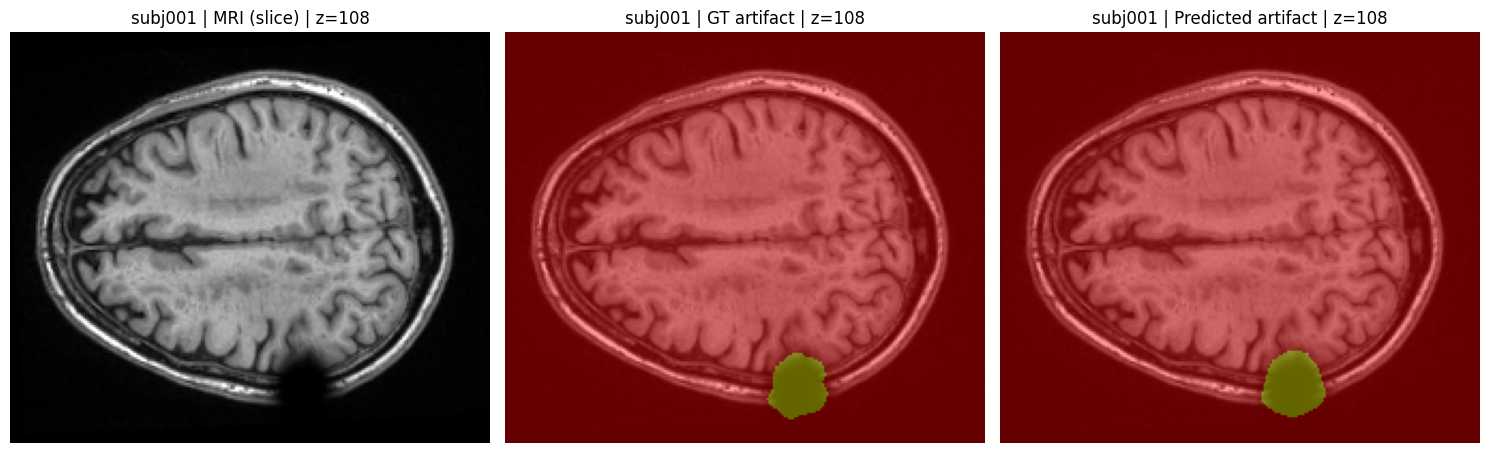

In [53]:
# Visualise prediction vs GT for the first evaluated subject.
vis_subj = next(
    (s for s in SUBJECTS
     if (PRED_DIR / f'{s}_taskA.nii.gz').exists()
     and (GT_DIR / s / f'{s}_artifact.nii.gz').exists()),
    None,
)

if vis_subj:
    img  = nib.load(str(GT_DIR / vis_subj / f'{vis_subj}_image.nii.gz')).get_fdata()
    pred = nib.load(str(PRED_DIR / f'{vis_subj}_taskA.nii.gz')).get_fdata()
    gt   = nib.load(str(GT_DIR / vis_subj / f'{vis_subj}_artifact.nii.gz')).get_fdata()

    # Find a slice with artifact voxels
    gt_slices = np.where(gt.sum(axis=(0, 1)) > 0)[0]
    z = int(gt_slices[len(gt_slices) // 2]) if len(gt_slices) else img.shape[2] // 2

    lo, hi = np.percentile(img, 1), np.percentile(img, 99)
    img_norm = np.clip((img - lo) / (hi - lo + 1e-8), 0, 1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    titles = ['MRI (slice)', 'GT artifact', 'Predicted artifact']
    masks  = [None, gt[:, :, z], pred[:, :, z]]
    for ax, title, mask in zip(axes, titles, masks):
        ax.imshow(img_norm[:, :, z], cmap='gray')
        if mask is not None:
            ax.imshow(mask, alpha=0.4, cmap='autumn')
        ax.set_title(f'{vis_subj} | {title} | z={z}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('No subjects available for visualisation.')